# **CSE422 ML**

# **Importing Files**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# **Load Dataset**

In [47]:
df = pd.read_csv('diabetes_dataset.csv')

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               90165 non-null  object 
 1   age                  89935 non-null  float64
 2   hypertension         89852 non-null  float64
 3   heart_disease        90081 non-null  float64
 4   smoking_history      90012 non-null  object 
 5   bmi                  90056 non-null  float64
 6   HbA1c_level          89861 non-null  float64
 7   blood_glucose_level  90120 non-null  float64
 8   diabetes             89918 non-null  float64
dtypes: float64(7), object(2)
memory usage: 6.9+ MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,89935.000000,89852.000000,90081.000000,90056.000000,89861.000000,90120.000000,89918.000000
mean,41.910520,0.075346,0.039143,27.311793,5.528352,137.995018,0.084900
std,22.506302,0.263950,0.193935,6.634078,1.070551,40.590751,0.278734
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.000000,0.000000,29.570000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


# **EDA + Correlation**

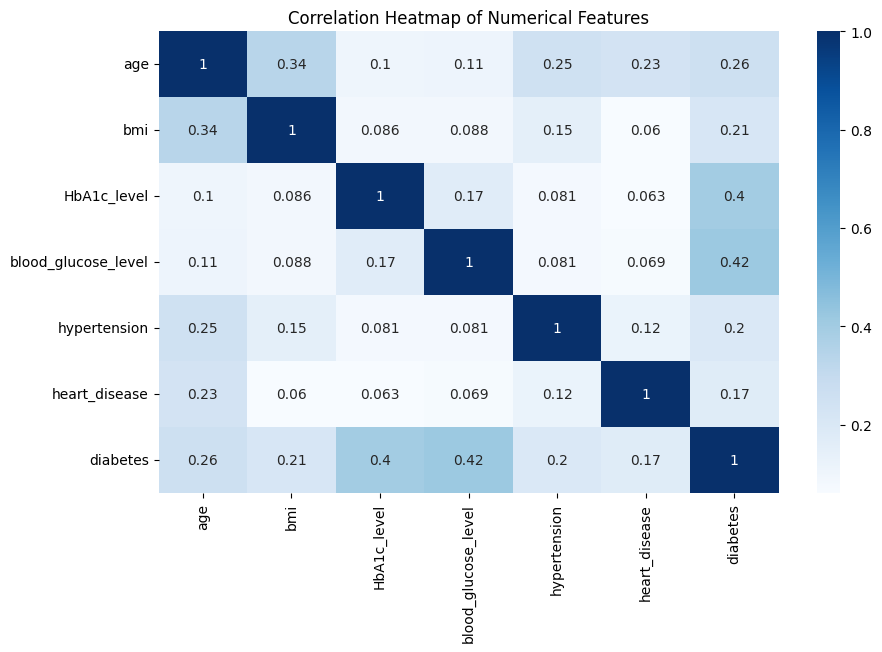

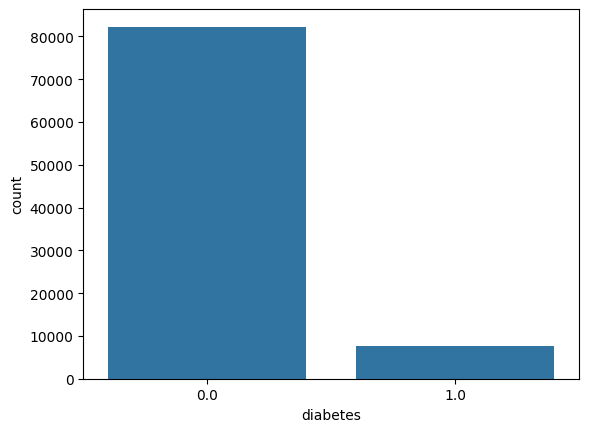

In [48]:
numeric_df = df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease', 'diabetes']]

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


sns.countplot(x='diabetes', data=df)
plt.show()


# **Preprocessing**

In [49]:
df.isnull().sum()

,0
gender,9835
age,10065
hypertension,10148
heart_disease,9919
smoking_history,9988
bmi,9944
HbA1c_level,10139
blood_glucose_level,9880
diabetes,10082


Duplicates

In [50]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98229 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               88438 non-null  object 
 1   age                  88830 non-null  float64
 2   hypertension         88111 non-null  float64
 3   heart_disease        88337 non-null  float64
 4   smoking_history      88300 non-null  object 
 5   bmi                  88512 non-null  float64
 6   HbA1c_level          88320 non-null  float64
 7   blood_glucose_level  88571 non-null  float64
 8   diabetes             88183 non-null  float64
dtypes: float64(7), object(2)
memory usage: 7.5+ MB


Missing Value

In [51]:
colmnsNumerical = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']
for col in colmnsNumerical:
  df[col].fillna(df[col].median(), inplace=True)

colmnsCatagorical = ['gender', 'smoking_history']
for col in colmnsCatagorical:
  df[col].fillna(df[col].mode()[0], inplace=True)

df.dropna(subset=['diabetes'], inplace=True)
df['diabetes'] = df['diabetes'].astype(int)

/tmp/ipython-input-2967361332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2967361332.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [52]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


Feature Distribution Analysis (Numerical)

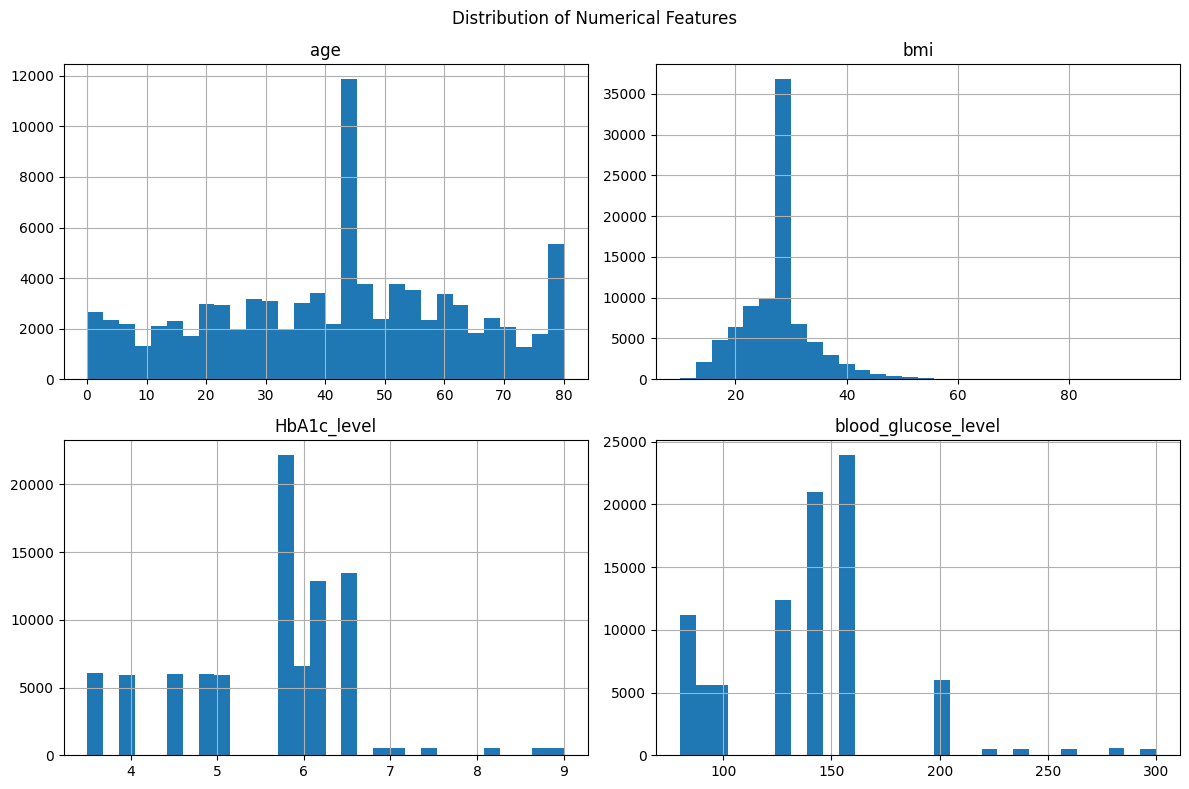

In [53]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

df[num_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

Label Encoding

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88183 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               88183 non-null  object 
 1   age                  88183 non-null  float64
 2   hypertension         88183 non-null  float64
 3   heart_disease        88183 non-null  float64
 4   smoking_history      88183 non-null  object 
 5   bmi                  88183 non-null  float64
 6   HbA1c_level          88183 non-null  float64
 7   blood_glucose_level  88183 non-null  float64
 8   diabetes             88183 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 6.7+ MB


In [55]:
lE = LabelEncoder()

df['gender'] = lE.fit_transform(df['gender'])
df['smoking_history'] = lE.fit_transform(df['smoking_history'])

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88183 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               88183 non-null  int64  
 1   age                  88183 non-null  float64
 2   hypertension         88183 non-null  float64
 3   heart_disease        88183 non-null  float64
 4   smoking_history      88183 non-null  int64  
 5   bmi                  88183 non-null  float64
 6   HbA1c_level          88183 non-null  float64
 7   blood_glucose_level  88183 non-null  float64
 8   diabetes             88183 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 6.7 MB


# **Split + Scale**

In [57]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [58]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training (Supervised)**

Decision Tree

In [59]:
dt = DecisionTreeClassifier(max_depth=6)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

KNN

In [60]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

Neural Network

In [61]:
nn = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)
nn.fit(X_train, y_train)
nn_pred = nn.predict(X_test)

## Model Selection and Comparison Analysis

Accuracy Bar Chart

{'Decision Tree': 0.9657153657153658, 'KNN': 0.9545265545265545, 'Neural Network': 0.964959364959365}


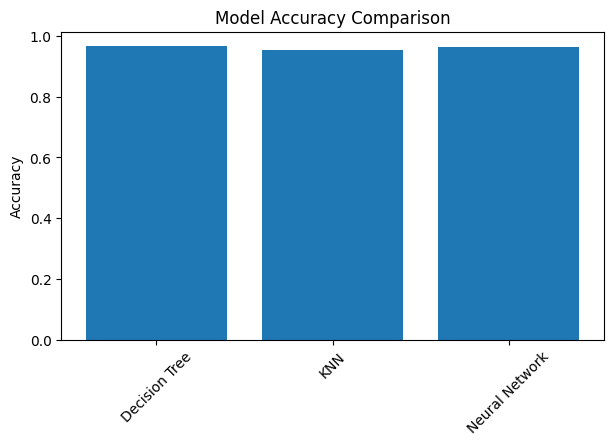

In [62]:
models_obj = {
    "Decision Tree": dt,
    "KNN": knn,
    "Neural Network": nn
}

results = {}

for name, model in models_obj.items():
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)

print(results)
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()


Precision & Recall Comparison

In [63]:
for name, model in models_obj.items():
    pred = model.predict(X_test)
    print(name)
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1-score:", f1_score(y_test, pred))
    print("-"*40)


Decision Tree
Precision: 1.0
Recall: 0.603583916083916
F1-score: 0.7527936767511584
----------------------------------------
KNN
Precision: 0.8557377049180328
Recall: 0.5703671328671329
F1-score: 0.6845003933910306
----------------------------------------
Neural Network
Precision: 0.9613559322033899
Recall: 0.6197552447552448
F1-score: 0.7536539994685092
----------------------------------------


Confusion Matrix

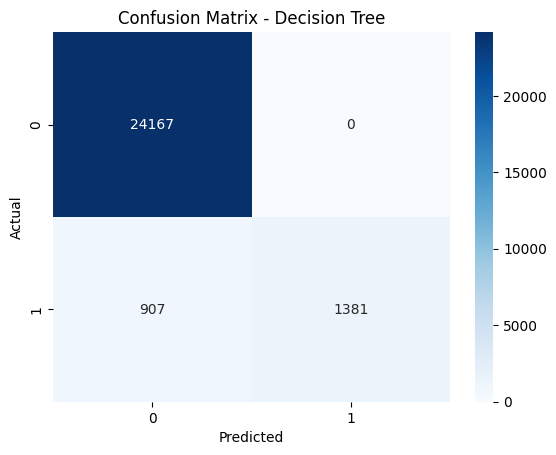

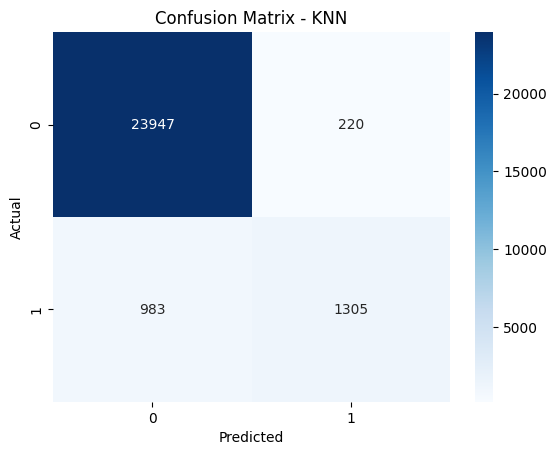

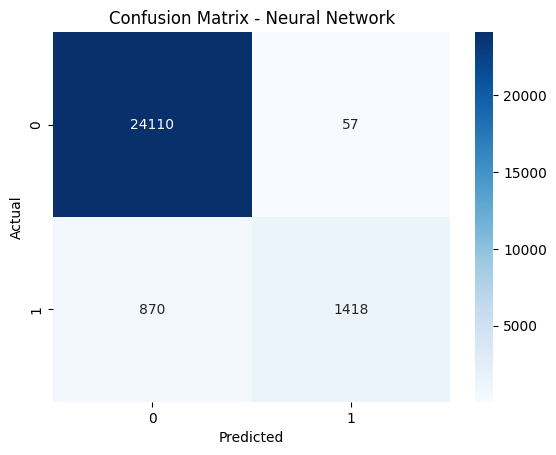

In [64]:
for name, model in models_obj.items():
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


ROC Curve + AUC Score

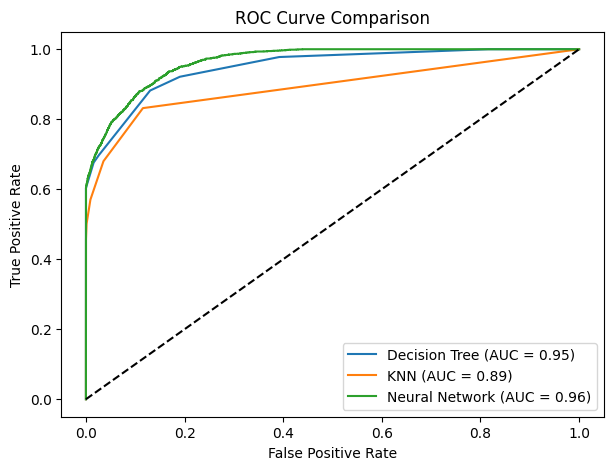

In [65]:
plt.figure(figsize=(7,5))

for name, model in models_obj.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# **KMeans (Unsupervised)**

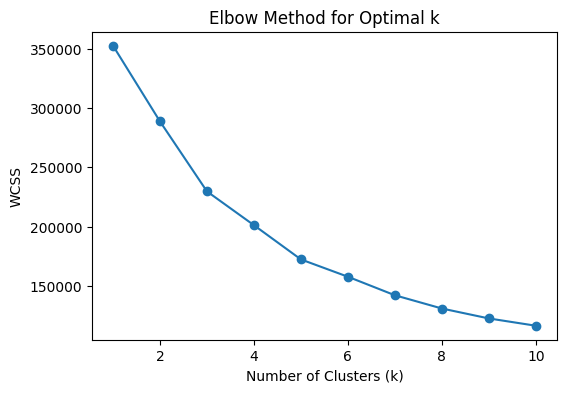

In [66]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
X_num = df[num_cols]

# Scale
X_scaled = StandardScaler().fit_transform(X_num)

# Elbow
wcss = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


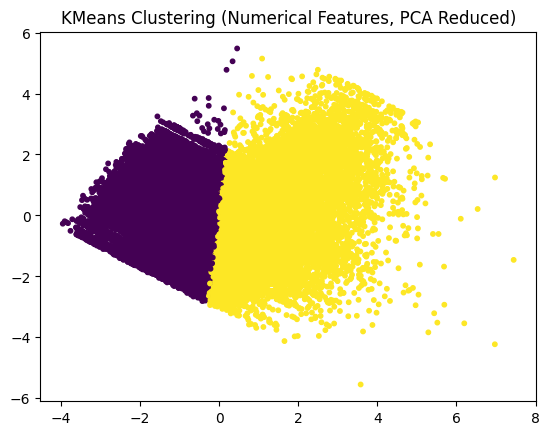

In [67]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', s=10)
plt.title("KMeans Clustering (Numerical Features, PCA Reduced)")
plt.show()